# Análisis de Datos e Inferencia Estadística
## 1. Preparación del entorno, carga y limpieza de datos
### Importación de librerías
Primero, importaremos las librerías necesarias y configuraremos nuestro entorno de análisis.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import os

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuramos pandas para mostrar más columnas
pd.set_option('display.max_columns', None)

### Configuración de visualización

In [22]:
# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuramos pandas para mostrar más columnas
pd.set_option('display.max_columns', None)

### Configuración de carga de archivos

In [ ]:
archivos = [
    ("../data/GRD_PUBLICO_EXTERNO_2022.txt", "utf-16"),
    ("../data/GRD_PUBLICO_2023.txt", "utf-16"),
    ("../data/GRD_PUBLICO_2024.txt", "latin-1"),
]

CHUNK_SIZE = 50000
output_file = "../data/datos_limpios.csv"

# Seleccionamos las columnas a utilizar
columnas_objetivo = [
    # Identificadores y Unicidad
    'COD_HOSPITAL',
    'CIP_ENCRIPTADO',

    # Demografía (Vulnerabilidad)
    'SEXO',
    'FECHA_NACIMIENTO',
    'PREVISION',
    'COMUNA',
    
    # Gestión y Flujo (Predictores)
    'TIPO_INGRESO',
    'ESPECIALIDAD_MEDICA',
    'FECHA_INGRESO',
    'FECHAALTA',
    'USOSPABELLON',
    
    # Severidad Clínica (Predictores)
    'IR_29301_SEVERIDAD',
    'IR_29301_MORTALIDAD',
    
    # Variable Objetivo (Target)
    'TIPOALTA'
]

# Agregar dinámicamente los 35 diagnósticos y 30 procedimientos
columnas_objetivo += [f'DIAGNOSTICO{i}' for i in range(1, 10)]
columnas_objetivo += [f'PROCEDIMIENTO{i}' for i in range(1, 10)]

# equivalencias de nombres
rename_map = {
    "ID_BENEFICIARIO": "CIP_ENCRIPTADO",
}

# detectar columnas de fecha
data_fechas = [col for col in columnas_objetivo if "fecha" in col.lower()]

### Función para formatear fechas con distintos formatos

In [24]:
def parse_fecha(col):
    # intento 1: ISO
    fecha = pd.to_datetime(col, format="%Y-%m-%d", errors="coerce")

    # intento 2: DD-MM-YYYY
    mask = fecha.isna()
    if mask.any():
        fecha.loc[mask] = pd.to_datetime(col[mask], format="%d-%m-%Y", errors="coerce")

    # intento 3: DD/MM/YYYY
    mask = fecha.isna()
    if mask.any():
        fecha.loc[mask] = pd.to_datetime(col[mask], format="%d/%m/%Y", errors="coerce")

    return fecha

### Procesamiento de los datos

In [ ]:
def procesar_datos():
    first = True

    for ruta, encoding in archivos:
        for chunk in pd.read_csv(
            ruta,
            encoding=encoding,
            sep="|",
            engine="python",
            on_bad_lines="skip",
            chunksize=CHUNK_SIZE
        ):
            # Limpiar nombres
            chunk.columns = chunk.columns.str.strip()

            # Renombrar
            chunk = chunk.rename(columns=rename_map)

            # Filtrar columnas después (más seguro)
            columnas_presentes = [c for c in columnas_objetivo if c in chunk.columns]
            chunk = chunk[columnas_presentes]

            # Agregar faltantes
            for col in columnas_objetivo:
                if col not in chunk.columns:
                    chunk[col] = pd.NA

            # Fechas
            for c in data_fechas:
                if c in chunk.columns:
                    chunk[c] = parse_fecha(chunk[c])

            # Orden final
            chunk = chunk[columnas_objetivo]

            # Guardar
            chunk.to_csv(
                output_file,
                mode="w" if first else "a",
                header=first,
                index=False,
                date_format="%Y-%m-%d"
            )

            first = False

    print("Archivo generado:", output_file)

### Ajustar tipo de datos

In [26]:
dtype = {
    # IDs / códigos
    "COD_HOSPITAL": "Int32",
    "CIP_ENCRIPTADO": "string",

    # categóricos / texto
    "SEXO": "string",
    "PREVISION": "string",
    "COMUNA": "string",
    "TIPO_INGRESO": "string",
    "ESPECIALIDAD_MEDICA": "string",
    "TIPOALTA": "string",

    # numéricos
    "USOSPABELLON": "float32",
    "IR_29301_SEVERIDAD": "Int8",
    "IR_29301_MORTALIDAD": "Int8",

    # diagnósticos (códigos tipo ICD)
    "DIAGNOSTICO1": "string",
    "DIAGNOSTICO2": "string",
    "DIAGNOSTICO3": "string",
    "DIAGNOSTICO4": "string",
    "DIAGNOSTICO5": "string",
    "DIAGNOSTICO6": "string",
    "DIAGNOSTICO7": "string",
    "DIAGNOSTICO8": "string",
    "DIAGNOSTICO9": "string",

    # procedimientos (códigos numéricos)
    "PROCEDIMIENTO1": "float32",
    "PROCEDIMIENTO2": "float32",
    "PROCEDIMIENTO3": "float32",
    "PROCEDIMIENTO4": "float32",
    "PROCEDIMIENTO5": "float32",
    "PROCEDIMIENTO6": "float32",
    "PROCEDIMIENTO7": "float32",
    "PROCEDIMIENTO8": "float32",
    "PROCEDIMIENTO9": "float32",
}

fechas = [
    "FECHA_NACIMIENTO",
    "FECHA_INGRESO",
    "FECHAALTA"
]

### Carga de los datos

In [ ]:
def cargar_o_procesar(output_file, procesar_func, force=False):
    if os.path.exists(output_file) and not force:
        print("Usando archivo existente")
    else:
        print("Generando archivo...")
        procesar_func()

    return pd.read_csv(output_file, dtype=dtype, parse_dates=fechas, na_values=["DESCONOCIDO"])

df = cargar_o_procesar("../data/datos_limpios.csv", procesar_datos)

📂 Usando archivo existente


### Eliminar datos anteriores a 2022

In [28]:
fecha_corte = pd.Timestamp("2022-01-01")

df = df[df["FECHA_INGRESO"] >= fecha_corte]

### Creamos variables útiles

In [29]:
df["EDAD"] = (
    (df["FECHA_INGRESO"] - df["FECHA_NACIMIENTO"])
    .dt.days // 365
)
df["AÑO"] = df["FECHA_INGRESO"].dt.year
df["DIAS_ESTADIA"] = (df["FECHAALTA"] - df["FECHA_INGRESO"]).dt.days

## 2. Exploración inicial

### Revisión de valores nulos

In [30]:
# Ver valores nulos
print(df.isnull().sum())

COD_HOSPITAL                 0
CIP_ENCRIPTADO            5602
SEXO                       207
FECHA_NACIMIENTO            20
PREVISION                  122
COMUNA                      83
TIPO_INGRESO               131
ESPECIALIDAD_MEDICA          0
FECHA_INGRESO                0
FECHAALTA                    0
USOSPABELLON           1195775
IR_29301_SEVERIDAD          67
IR_29301_MORTALIDAD         67
TIPOALTA                     0
DIAGNOSTICO1               147
DIAGNOSTICO2            414943
DIAGNOSTICO3            787450
DIAGNOSTICO4           1165569
DIAGNOSTICO5           1531094
DIAGNOSTICO6           1847465
DIAGNOSTICO7           2107954
DIAGNOSTICO8           2316874
DIAGNOSTICO9           2480298
PROCEDIMIENTO1             420
PROCEDIMIENTO2          247100
PROCEDIMIENTO3          507094
PROCEDIMIENTO4          752672
PROCEDIMIENTO5          982363
PROCEDIMIENTO6         1209027
PROCEDIMIENTO7         1436119
PROCEDIMIENTO8         1659666
PROCEDIMIENTO9         1871957
EDAD    

### Revisión de outliers

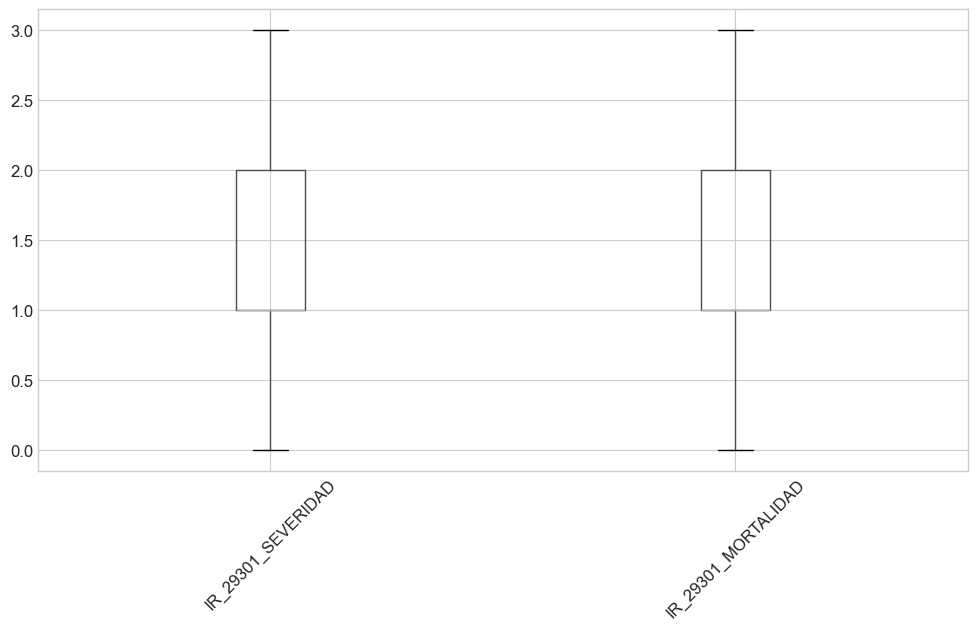

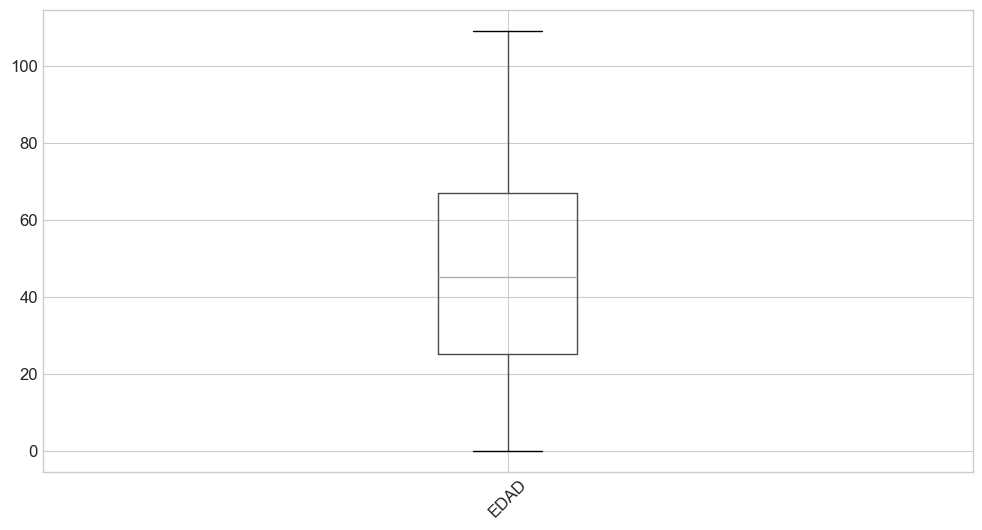

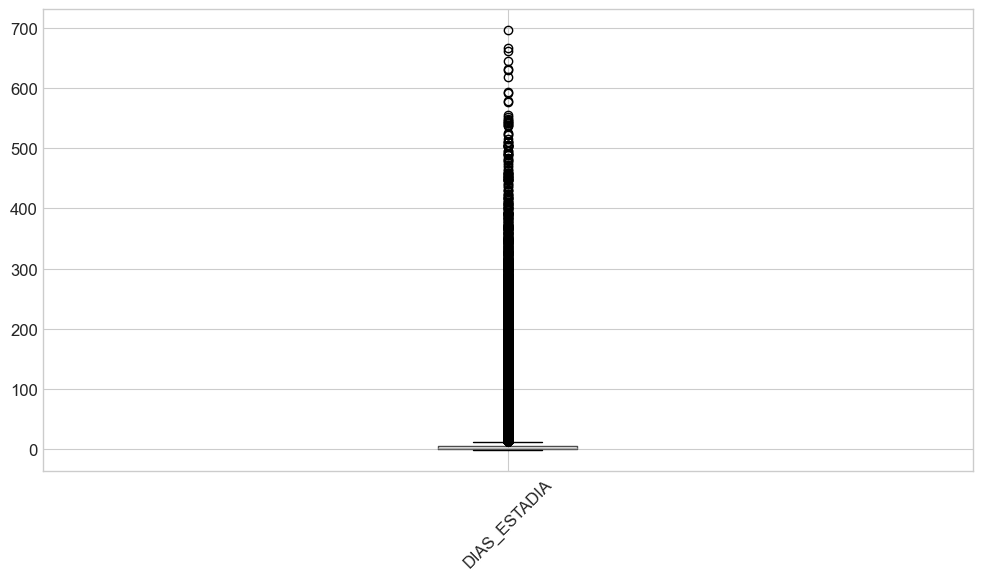

In [31]:
df.boxplot(column=["IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

df.boxplot(column=["EDAD"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

df.boxplot(column=["DIAS_ESTADIA"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [32]:
cols_numericas = ["IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD", "EDAD", "DIAS_ESTADIA"]

Q1 = df[cols_numericas].quantile(0.25)
Q3 = df[cols_numericas].quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (df[cols_numericas] < (Q1 - 1.5 * IQR)) |
    (df[cols_numericas] > (Q3 + 1.5 * IQR))
)

# por columna
print(outliers.sum())

# filas afectadas
print("Filas con outliers:", outliers.any(axis=1).sum())

IR_29301_SEVERIDAD          0
IR_29301_MORTALIDAD         0
EDAD                        0
DIAS_ESTADIA           311815
dtype: Int64
Filas con outliers: 311815


In [33]:
df.dtypes

COD_HOSPITAL                    Int32
CIP_ENCRIPTADO                 string
SEXO                           string
FECHA_NACIMIENTO       datetime64[us]
PREVISION                      string
COMUNA                         string
TIPO_INGRESO                   string
ESPECIALIDAD_MEDICA            string
FECHA_INGRESO          datetime64[us]
FECHAALTA              datetime64[us]
USOSPABELLON                  float32
IR_29301_SEVERIDAD               Int8
IR_29301_MORTALIDAD              Int8
TIPOALTA                       string
DIAGNOSTICO1                   string
DIAGNOSTICO2                   string
DIAGNOSTICO3                   string
DIAGNOSTICO4                   string
DIAGNOSTICO5                   string
DIAGNOSTICO6                   string
DIAGNOSTICO7                   string
DIAGNOSTICO8                   string
DIAGNOSTICO9                   string
PROCEDIMIENTO1                float32
PROCEDIMIENTO2                float32
PROCEDIMIENTO3                float32
PROCEDIMIENT

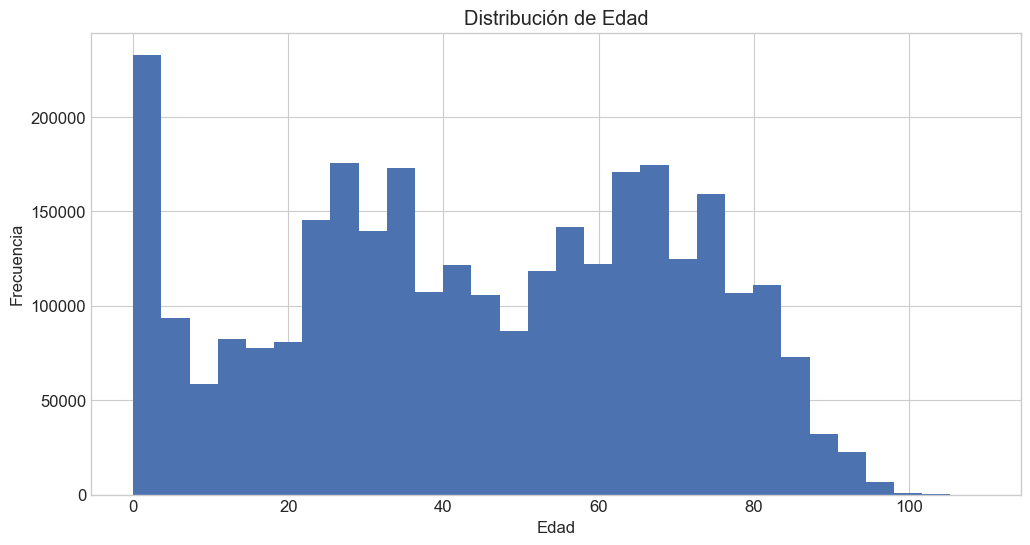

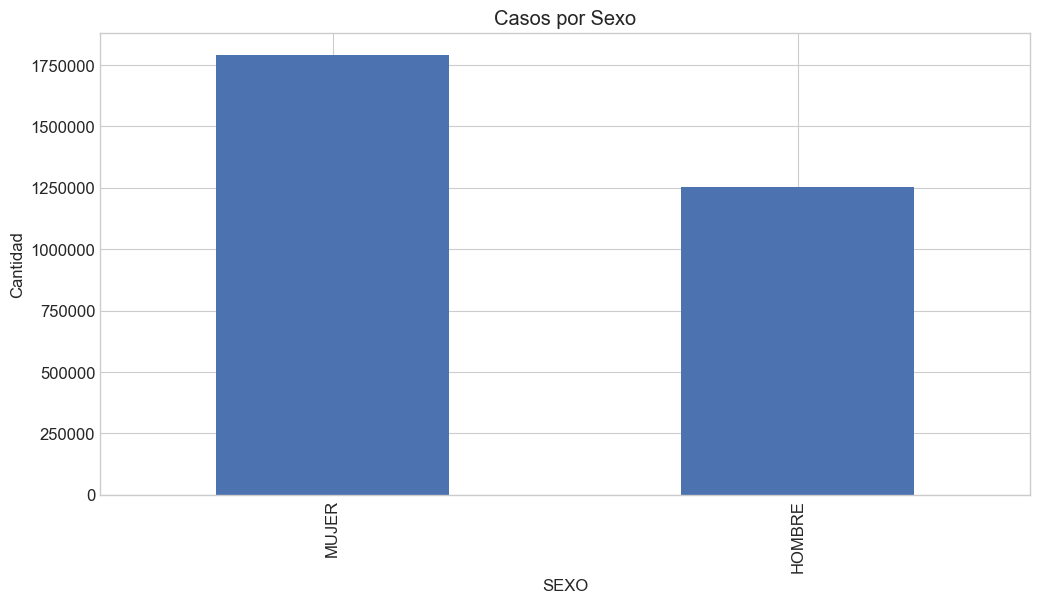

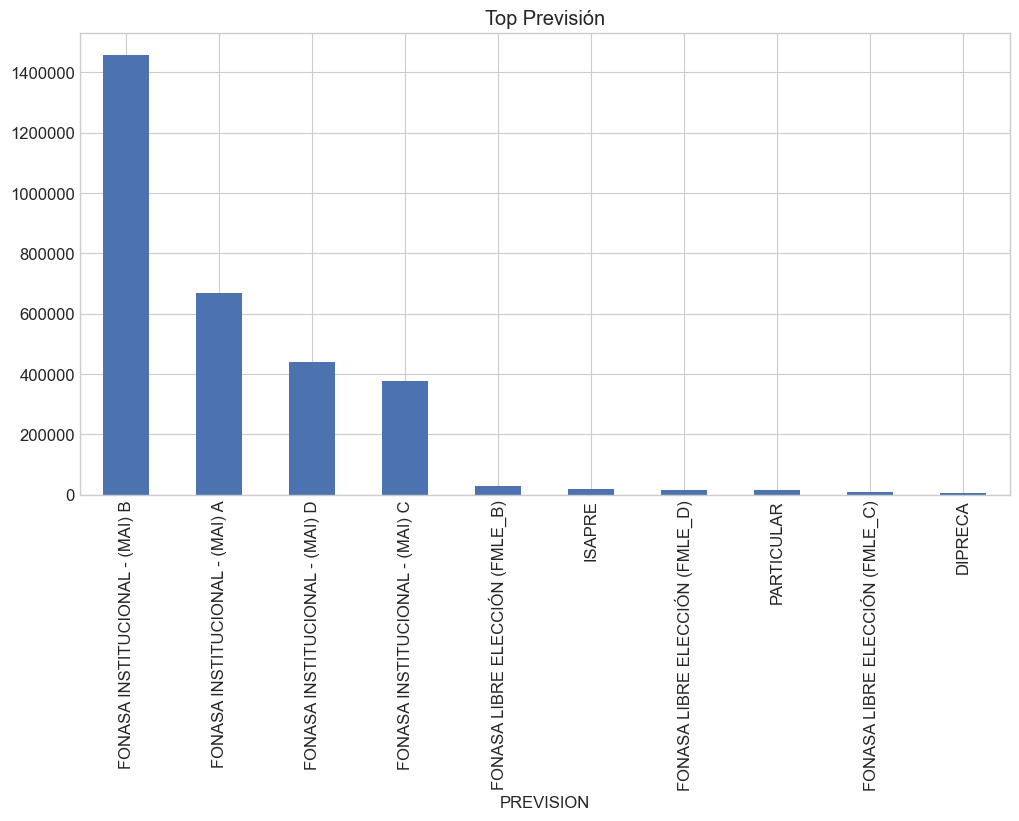

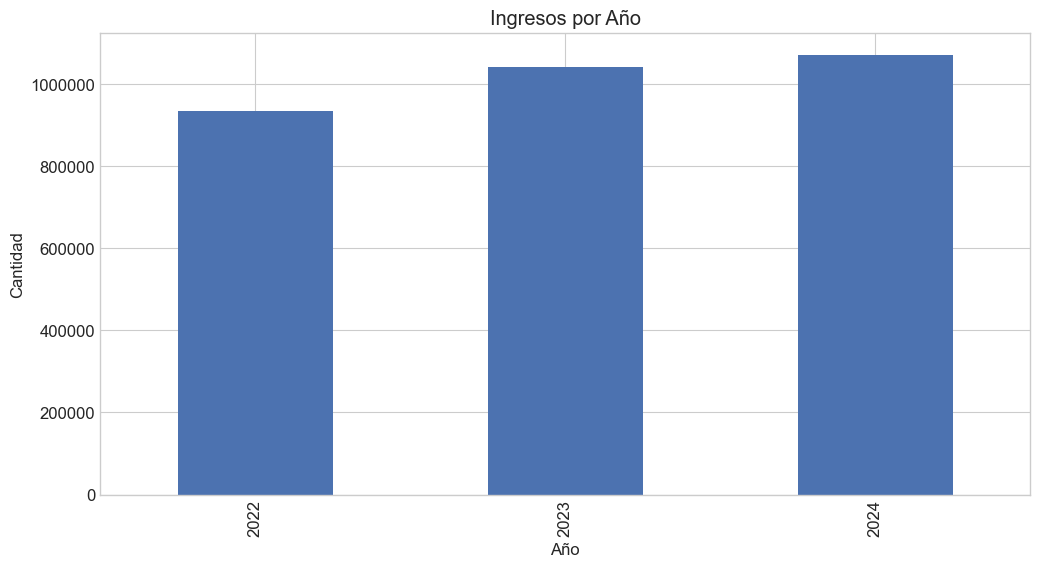

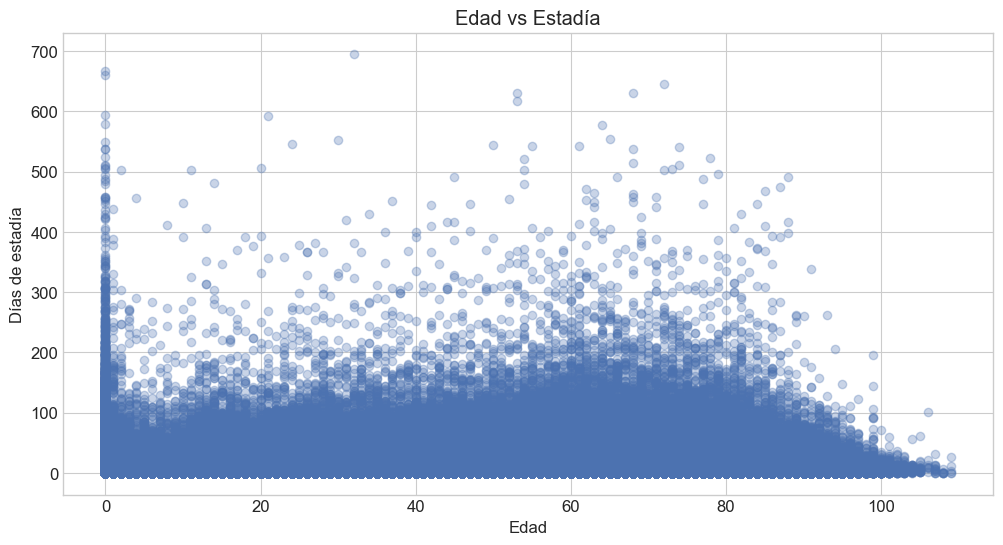

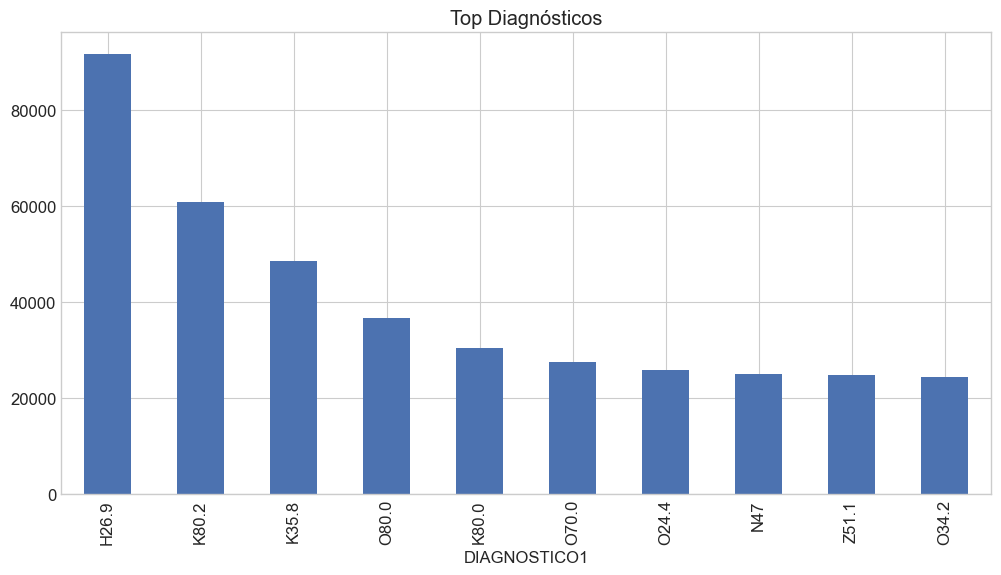

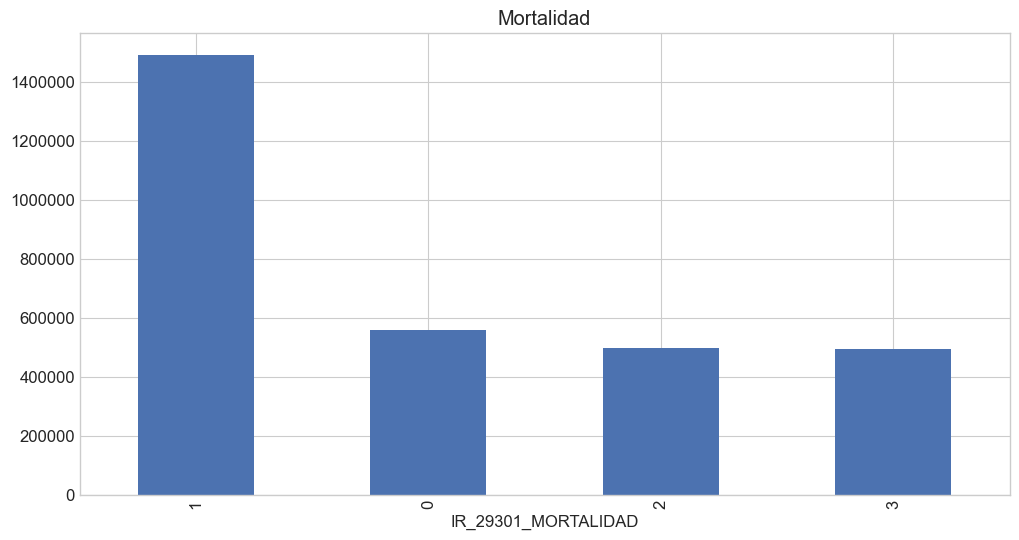

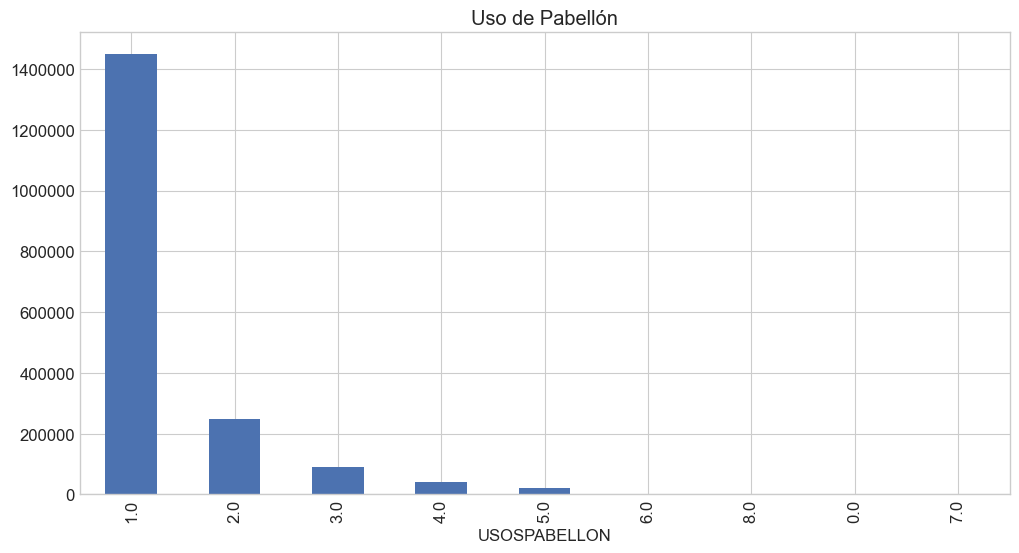

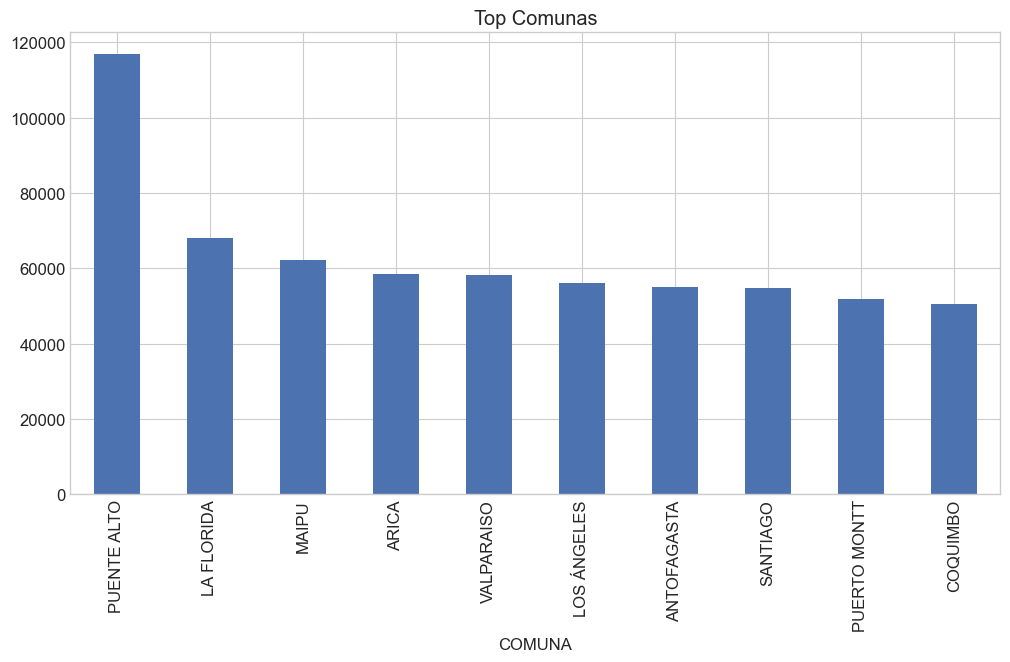

In [ ]:

# Distribución de Edad
plt.figure()
df["EDAD"].hist(bins=30)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

# Casos por Sexo
plt.figure()
df["SEXO"].value_counts().plot(kind="bar")
plt.title("Casos por Sexo")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Cantidad")
plt.show()

# Casos por Previsión
plt.figure()
df["PREVISION"].value_counts().head(10).plot(kind="bar")
plt.title("Top Previsión")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Ingresos por Año
plt.figure()
df["AÑO"].value_counts().sort_index().plot(kind="bar")
plt.title("Ingresos por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.ticklabel_format(style='plain', axis='y')  # 🔥 solución
plt.show()

# Edad vs estadía
plt.figure()
plt.scatter(df["EDAD"], df["DIAS_ESTADIA"], alpha=0.3)
plt.xlabel("Edad")
plt.ylabel("Días de estadía")
plt.title("Edad vs Estadía")
plt.show()

# Top diagnósticos
plt.figure()
df["DIAGNOSTICO1"].value_counts().head(10).plot(kind="bar")
plt.title("Top Diagnósticos")
plt.show()

# Mortalidad
if "IR_29301_MORTALIDAD" in df.columns:
    plt.figure()
    df["IR_29301_MORTALIDAD"].value_counts().plot(kind="bar")
    plt.title("Mortalidad")
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

# Uso de pabellón
if "USOSPABELLON" in df.columns:
    plt.figure()
    df["USOSPABELLON"].value_counts().plot(kind="bar")
    plt.title("Uso de Pabellón")
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

# Top comunas
plt.figure()
df["COMUNA"].value_counts().head(10).plot(kind="bar")
plt.title("Top Comunas")
plt.show()

In [52]:
casos_raros = df[(df["EDAD"] == 0) & (df["DIAS_ESTADIA"] > 350)]
display(casos_raros[["FECHA_INGRESO", "FECHAALTA", "ESPECIALIDAD_MEDICA", "TIPO_INGRESO", "TIPOALTA"]])

,FECHA_INGRESO,FECHAALTA,ESPECIALIDAD_MEDICA,TIPO_INGRESO,TIPOALTA
1073460,2022-02-05,2023-12-04,NEONATOLOGÍA,URGENCIA,HOSPITALIZACIÓN DOMICILIARIA
1116380,2022-03-20,2023-05-17,PEDIATRÍA,URGENCIA,DOMICILIO
1130739,2022-08-14,2023-08-08,PEDIATRÍA,URGENCIA,DOMICILIO
1226284,2022-03-03,2023-05-29,PEDIATRÍA,URGENCIA,DOMICILIO
1338195,2022-03-22,2023-06-19,PEDIATRÍA,URGENCIA,DOMICILIO
1338200,2022-08-20,2023-08-10,PEDIATRÍA,URGENCIA,DOMICILIO
1356652,2022-07-15,2023-12-22,CIRUGÍA PEDIÁTRICA,URGENCIA,DOMICILIO
1463108,2022-05-30,2023-05-16,PEDIATRÍA,URGENCIA,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE"
1506825,2022-02-04,2023-06-14,PEDIATRÍA,URGENCIA,DOMICILIO
1519252,2022-04-07,2023-06-05,PEDIATRÍA,PROGRAMADA,DOMICILIO


---
## 3. Índice de Comorbilidad de Charlson (CCI)

El **Índice de Comorbilidad de Charlson (CCI)** es un sistema de puntuación validado internacionalmente que cuantifica la carga de enfermedades crónicas de un paciente. Cada condición tiene un peso (1 a 6 puntos) según su impacto esperado en la mortalidad a 10 años. La suma de estos pesos constituye el score final del paciente.

Utilizamos este índice porque:
- La literatura clínica (Charlson et al., 1987; Quan et al., 2011) lo valida como predictor robusto de mortalidad intrahospitalaria.
- Nuestra hipótesis plantea que las **comorbilidades** son predictores primarios — el CCI permite cuantificar exactamente esa carga.
- Los códigos ICD-10 presentes en las columnas `DIAGNOSTICO1`–`DIAGNOSTICO9` del dataset GRD permiten mapear directamente las condiciones.

### Categorías del CCI
| Score | Interpretación |
|-------|----------------|
| 0 | Sin comorbilidades relevantes |
| 1–2 | Comorbilidad leve |
| 3–4 | Comorbilidad moderada |
| ≥ 5 | Comorbilidad severa |

### 3.1 Mapeo ICD-10 → Categorías Charlson

In [ ]:
# ============================================================
# ÍNDICE DE COMORBILIDAD DE CHARLSON — IMPLEMENTACIÓN PROPIA
# Referencia: Quan et al. (2011) Med Care, 49(6), 612–617.
#             Charlson et al. (1987) J Chronic Dis, 40(5), 373–383.
# ============================================================

# Mapeamos prefijos ICD-10 (3 caracteres) a la categoría Charlson.
# Cada categoría tiene un peso según el modelo original de Charlson
# actualizado por Quan et al. (2011).

CHARLSON_ICD10 = {
    # ── Peso 1 ──────────────────────────────────────────────
    # Infarto agudo de miocardio
    'I21': ('MI', 1), 'I22': ('MI', 1), 'I25': ('MI', 1),
    # Insuficiencia cardíaca congestiva
    'I50': ('CHF', 1),
    # Enfermedad vascular periférica
    'I70': ('PVD', 1), 'I71': ('PVD', 1), 'I73': ('PVD', 1),
    'I77': ('PVD', 1), 'I79': ('PVD', 1),
    # Enfermedad cerebrovascular
    'G45': ('CVD', 1), 'G46': ('CVD', 1),
    'I60': ('CVD', 1), 'I61': ('CVD', 1), 'I62': ('CVD', 1),
    'I63': ('CVD', 1), 'I64': ('CVD', 1), 'I65': ('CVD', 1),
    'I66': ('CVD', 1), 'I67': ('CVD', 1), 'I68': ('CVD', 1),
    'I69': ('CVD', 1),
    # Demencia
    'F00': ('DEM', 1), 'F01': ('DEM', 1), 'F02': ('DEM', 1),
    'F03': ('DEM', 1), 'G30': ('DEM', 1), 'G31': ('DEM', 1),
    # Enfermedad pulmonar crónica (EPOC)
    'J40': ('COPD', 1), 'J41': ('COPD', 1), 'J42': ('COPD', 1),
    'J43': ('COPD', 1), 'J44': ('COPD', 1), 'J45': ('COPD', 1),
    'J46': ('COPD', 1), 'J47': ('COPD', 1), 'J60': ('COPD', 1),
    'J61': ('COPD', 1), 'J62': ('COPD', 1), 'J63': ('COPD', 1),
    'J64': ('COPD', 1), 'J65': ('COPD', 1), 'J66': ('COPD', 1),
    'J67': ('COPD', 1),
    # Enfermedad del tejido conectivo
    'M05': ('RHD', 1), 'M06': ('RHD', 1), 'M32': ('RHD', 1),
    'M33': ('RHD', 1), 'M34': ('RHD', 1), 'M35': ('RHD', 1),
    # Úlcera péptica
    'K25': ('PUD', 1), 'K26': ('PUD', 1), 'K27': ('PUD', 1),
    'K28': ('PUD', 1),
    # Enfermedad hepática leve
    'B18': ('MLD', 1), 'K70': ('MLD', 1), 'K71': ('MLD', 1),
    'K73': ('MLD', 1), 'K74': ('MLD', 1), 'K76': ('MLD', 1),
    # Diabetes sin complicación
    'E10': ('DM', 1), 'E11': ('DM', 1), 'E12': ('DM', 1),
    'E13': ('DM', 1), 'E14': ('DM', 1),

    # ── Peso 2 ──────────────────────────────────────────────
    # Hemiplejia
    'G04': ('HEMI', 2), 'G81': ('HEMI', 2), 'G82': ('HEMI', 2),
    'G83': ('HEMI', 2),
    # Enfermedad renal moderada/severa
    'N03': ('REN', 2), 'N05': ('REN', 2), 'N18': ('REN', 2),
    'N19': ('REN', 2), 'N25': ('REN', 2),
    # Diabetes con complicación crónica
    'E102': ('DMC', 2), 'E112': ('DMC', 2), 'E122': ('DMC', 2),
    'E132': ('DMC', 2), 'E142': ('DMC', 2),
    # Tumor sólido sin metástasis
    'C00': ('TUM', 2), 'C01': ('TUM', 2), 'C02': ('TUM', 2),
    'C03': ('TUM', 2), 'C04': ('TUM', 2), 'C05': ('TUM', 2),
    'C06': ('TUM', 2), 'C07': ('TUM', 2), 'C08': ('TUM', 2),
    'C09': ('TUM', 2), 'C10': ('TUM', 2), 'C11': ('TUM', 2),
    'C12': ('TUM', 2), 'C13': ('TUM', 2), 'C14': ('TUM', 2),
    'C15': ('TUM', 2), 'C16': ('TUM', 2), 'C17': ('TUM', 2),
    'C18': ('TUM', 2), 'C19': ('TUM', 2), 'C20': ('TUM', 2),
    'C21': ('TUM', 2), 'C22': ('TUM', 2), 'C23': ('TUM', 2),
    'C24': ('TUM', 2), 'C25': ('TUM', 2), 'C26': ('TUM', 2),
    'C30': ('TUM', 2), 'C31': ('TUM', 2), 'C32': ('TUM', 2),
    'C33': ('TUM', 2), 'C34': ('TUM', 2), 'C37': ('TUM', 2),
    'C38': ('TUM', 2), 'C39': ('TUM', 2), 'C40': ('TUM', 2),
    'C41': ('TUM', 2), 'C43': ('TUM', 2), 'C45': ('TUM', 2),
    'C46': ('TUM', 2), 'C47': ('TUM', 2), 'C48': ('TUM', 2),
    'C49': ('TUM', 2), 'C50': ('TUM', 2), 'C51': ('TUM', 2),
    'C52': ('TUM', 2), 'C53': ('TUM', 2), 'C54': ('TUM', 2),
    'C55': ('TUM', 2), 'C56': ('TUM', 2), 'C57': ('TUM', 2),
    'C58': ('TUM', 2), 'C60': ('TUM', 2), 'C61': ('TUM', 2),
    'C62': ('TUM', 2), 'C63': ('TUM', 2), 'C64': ('TUM', 2),
    'C65': ('TUM', 2), 'C66': ('TUM', 2), 'C67': ('TUM', 2),
    'C68': ('TUM', 2), 'C69': ('TUM', 2), 'C70': ('TUM', 2),
    'C71': ('TUM', 2), 'C72': ('TUM', 2), 'C73': ('TUM', 2),
    'C74': ('TUM', 2), 'C75': ('TUM', 2), 'C76': ('TUM', 2),
    'C97': ('TUM', 2),
    # Leucemia
    'C91': ('LEU', 2), 'C92': ('LEU', 2), 'C93': ('LEU', 2),
    'C94': ('LEU', 2), 'C95': ('LEU', 2),
    # Linfoma
    'C81': ('LYM', 2), 'C82': ('LYM', 2), 'C83': ('LYM', 2),
    'C84': ('LYM', 2), 'C85': ('LYM', 2), 'C88': ('LYM', 2),
    'C90': ('LYM', 2),

    # ── Peso 3 ──────────────────────────────────────────────
    # Enfermedad hepática moderada/severa
    'K70': ('MSLD', 3), 'K72': ('MSLD', 3), 'K76': ('MSLD', 3),

    # ── Peso 6 ──────────────────────────────────────────────
    # Tumor sólido con metástasis
    'C77': ('METS', 6), 'C78': ('METS', 6),
    'C79': ('METS', 6), 'C80': ('METS', 6),
    # VIH / SIDA
    'B20': ('AIDS', 6), 'B21': ('AIDS', 6),
    'B22': ('AIDS', 6), 'B24': ('AIDS', 6),
}

print(f" Mapa Charlson cargado: {len(CHARLSON_ICD10)} prefijos ICD-10 mapeados")
print(f"Categorías únicas: {len(set(v[0] for v in CHARLSON_ICD10.values()))}")

### 3.2 Función de cálculo del CCI por paciente

In [ ]:
def match_charlson(codigo: str) -> tuple | None:
    """
    Recibe un código ICD-10 (ej: 'I5000', 'J44', 'C34X').
    Devuelve (categoria, peso) si hay match, o None si no aplica.
    
    Estrategia: probar prefijos de longitud 5, 4 y 3 en orden.
    Esto permite capturar tanto los códigos de 5 dígitos (diabetes
    con complicación, ej 'E102') como los genéricos de 3 dígitos.
    """
    if not isinstance(codigo, str):
        return None
    # Normalizar: mayúsculas, sin espacios, sin guiones
    cod = codigo.upper().strip().replace('-', '').replace(' ', '')
    # Intentar match por prefijo decreciente (5 → 4 → 3 chars)
    for length in (5, 4, 3):
        prefijo = cod[:length]
        if prefijo in CHARLSON_ICD10:
            return CHARLSON_ICD10[prefijo]
    return None


# Columnas de diagnóstico disponibles en el dataset
COLS_DIAGNOSTICO = [f'DIAGNOSTICO{i}' for i in range(1, 10)]


def calcular_cci(fila: pd.Series, cols_dx: list[str]) -> int:
    """
    Calcula el Índice de Comorbilidad de Charlson para una fila del dataframe.
    
    Parámetros
    ----------
    fila     : pd.Series — una fila del dataframe
    cols_dx  : list[str] — nombres de columnas de diagnóstico ICD-10
    
    Retorna
    -------
    int — score CCI (0 = sin comorbilidades)
    
    Nota: cada categoría Charlson se cuenta UNA sola vez, aunque el
    paciente tenga múltiples diagnósticos que caigan en la misma.
    """
    categorias_presentes = {}  # {categoria: peso}
    
    for col in cols_dx:
        codigo = fila.get(col)
        resultado = match_charlson(codigo)
        if resultado is not None:
            categoria, peso = resultado
            # Guardar el peso más alto si hay categorías duplicadas
            if categoria not in categorias_presentes:
                categorias_presentes[categoria] = peso
            else:
                categorias_presentes[categoria] = max(
                    categorias_presentes[categoria], peso
                )
    
    return sum(categorias_presentes.values())


print("Funciones match_charlson() y calcular_cci() definidas")

# Test unitario rápido
test_cases = [
    ('I50', 'CHF', 1),
    ('J440', 'COPD', 1),
    ('C34',  'TUM', 2),
    ('C79',  'METS', 6),
    ('B20',  'AIDS', 6),
    ('XYZ',  None, None),
]
print("\nTest unitario match_charlson():")
all_ok = True
for cod, cat_esperada, peso_esperado in test_cases:
    result = match_charlson(cod)
    if cat_esperada is None:
        ok = result is None
    else:
        ok = result is not None and result[0] == cat_esperada and result[1] == peso_esperado
    status = '✅' if ok else '❌'
    if not ok:
        all_ok = False
    print(f"{status} '{cod}' → esperado ({cat_esperada}, {peso_esperado}), obtenido {result}")
print("\nTodos los tests OK" if all_ok else "\n Revisar tests fallidos")

### 3.3 Aplicación al dataset: columna `CCI`

Aplicamos `calcular_cci()` a cada fila del dataframe usando `.apply()`. El resultado se guarda en la nueva columna `CCI`.

> **Nota de rendimiento**: con datasets grandes (~millones de filas), `.apply()` fila a fila puede ser lento. Si el tiempo de cómputo es crítico, el siguiente enfoque vectorizado por columna de diagnóstico es notablemente más rápido — está incluido como alternativa comentada al final de la celda.

In [ ]:
# ── Verificar que las columnas de diagnóstico existen en df ──────────────
cols_disponibles = [c for c in COLS_DIAGNOSTICO if c in df.columns]
cols_faltantes   = [c for c in COLS_DIAGNOSTICO if c not in df.columns]

if cols_faltantes:
    print(f" Columnas no encontradas (se ignorarán): {cols_faltantes}")
print(f" Columnas de diagnóstico disponibles: {cols_disponibles}")

# ── Calcular CCI ─────────────────────────────────────────────────────────
print("\nCalculando CCI...")
df['CCI'] = df.apply(
    calcular_cci,
    cols_dx=cols_disponibles,
    axis=1
)
print(f"Columna 'CCI' creada. Shape: {df.shape}")

# ── Alternativa vectorizada (más rápida para datasets muy grandes) ────────
# Descomentar si .apply() es demasiado lento:
#
# peso_map = {cod: peso for cod, (_, peso) in CHARLSON_ICD10.items()}
#
# def puntaje_col(series: pd.Series) -> pd.Series:
#     prefijo3 = series.str.upper().str[:3].fillna('')
#     return prefijo3.map(peso_map).fillna(0).astype(int)
#
# cci_matrix = pd.concat(
#     [puntaje_col(df[c]) for c in cols_disponibles], axis=1
# )
# df['CCI'] = cci_matrix.max(axis=1)  # o .sum() según enfoque

### 3.4 Distribución del CCI y categorización

In [ ]:
# ── Crear variable categórica ─────────────────────────────────────────────
bins   = [-1, 0, 2, 4, 100]
labels = ['Sin comorbilidades (0)',
          'Leve (1–2)',
          'Moderada (3–4)',
          'Severa (≥5)']

df['CCI_CAT'] = pd.cut(df['CCI'], bins=bins, labels=labels)

# ── Estadísticas descriptivas ─────────────────────────────────────────────
print("=== Estadísticas del CCI ===")
print(df['CCI'].describe().round(3))

print("\n=== Distribución por categoría ===")
dist = df['CCI_CAT'].value_counts().sort_index()
print(dist)
print(f"\nPorcentajes:")
print((dist / len(df) * 100).round(2))

In [ ]:
# ── Visualización: distribución del CCI ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de scores
ax1 = axes[0]
df['CCI'].value_counts().sort_index().plot(
    kind='bar', ax=ax1, color='steelblue', edgecolor='white'
)
ax1.set_title('Distribución del Índice de Charlson (CCI)', fontsize=13, pad=10)
ax1.set_xlabel('Score CCI')
ax1.set_ylabel('Número de hospitalizaciones')
ax1.ticklabel_format(style='plain', axis='y')

# Pie por categoría
ax2 = axes[1]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
df['CCI_CAT'].value_counts().sort_index().plot(
    kind='pie', ax=ax2, autopct='%1.1f%%',
    colors=colors, startangle=140,
    textprops={'fontsize': 10}
)
ax2.set_title('Categorías del CCI', fontsize=13, pad=10)
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

### 3.5 CCI vs Mortalidad intrahospitalaria

Exploramos si existe una relación visible entre la carga de comorbilidades (CCI) y la mortalidad durante la hospitalización (`TIPOALTA`). Esto constituye el análisis exploratorio central de nuestra pregunta de investigación.

In [ ]:
# ── Crear variable binaria de mortalidad ─────────────────────────────────
# TIPOALTA = '2' corresponde a fallecimiento en la mayoría de codificaciones GRD
# Ajustar el valor si el dataset usa otra codificación
df['FALLECIDO'] = df['TIPOALTA'].astype(str).str.strip().isin(['2', '02', 'FALLECIDO'])

print(f"Registros con fallecimiento: {df['FALLECIDO'].sum():,}")
print(f"Tasa de mortalidad global: {df['FALLECIDO'].mean():.3%}")

# ── Tasa de mortalidad por categoría CCI ─────────────────────────────────
mortalidad_por_cci = (
    df.groupby('CCI_CAT', observed=True)['FALLECIDO']
      .agg(['sum', 'mean', 'count'])
      .rename(columns={'sum': 'Fallecidos', 'mean': 'Tasa', 'count': 'Total'})
)
mortalidad_por_cci['Tasa_%'] = (mortalidad_por_cci['Tasa'] * 100).round(2)

print("\n=== Mortalidad por categoría CCI ===")
print(mortalidad_por_cci[['Total', 'Fallecidos', 'Tasa_%']])

In [ ]:
# ── Visualización: CCI vs mortalidad ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: tasa de mortalidad por categoría
ax1 = axes[0]
cats = mortalidad_por_cci.index.astype(str)
tasas = mortalidad_por_cci['Tasa_%']
bars = ax1.bar(cats, tasas, color=['#2ecc71','#3498db','#f39c12','#e74c3c'],
               edgecolor='white', width=0.55)
ax1.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax1.set_title('Tasa de Mortalidad por Categoría CCI', fontsize=12)
ax1.set_xlabel('Categoría CCI')
ax1.set_ylabel('Tasa de mortalidad (%)')
ax1.set_xticklabels(cats, rotation=15, ha='right')

# Gráfico 2: boxplot CCI (vivos vs fallecidos)
ax2 = axes[1]
df.boxplot(
    column='CCI', by='FALLECIDO', ax=ax2,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='orange', linewidth=2)
)
ax2.set_title('CCI: Vivos vs Fallecidos', fontsize=12)
ax2.set_xlabel('Fallecido')
ax2.set_ylabel('Score CCI')
plt.suptitle('')  # elimina el título automático de boxplot

plt.tight_layout()
plt.show()

### 3.6 Estimación estadística: CCI como predictor

Calculamos estimadores puntuales del CCI separando pacientes fallecidos de los no fallecidos, y construimos intervalos de confianza al 95% para la media del CCI en cada grupo.

In [ ]:
from scipy import stats as scipy_stats

# ── Estimadores por grupo ─────────────────────────────────────────────────
grupos = {
    'Vivos':     df[df['FALLECIDO'] == False]['CCI'].dropna(),
    'Fallecidos': df[df['FALLECIDO'] == True]['CCI'].dropna(),
}

print(f"{'Grupo':<14} {'n':>8} {'Media':>8} {'Mediana':>9} {'Std':>8} {'IC95% inf':>11} {'IC95% sup':>11}")
print("-" * 75)

for nombre, serie in grupos.items():
    n     = len(serie)
    media = serie.mean()
    med   = serie.median()
    std   = serie.std()
    sem   = scipy_stats.sem(serie)
    ci    = scipy_stats.t.interval(0.95, df=n-1, loc=media, scale=sem)
    print(f"{nombre:<14} {n:>8,} {media:>8.3f} {med:>9.1f} {std:>8.3f} "
          f"{ci[0]:>11.3f} {ci[1]:>11.3f}")

# ── Prueba Mann-Whitney (distribución no normal esperada) ─────────────────
print("\n=== Prueba Mann-Whitney U (CCI: Vivos vs Fallecidos) ===")
stat, p_val = scipy_stats.mannwhitneyu(
    grupos['Vivos'], grupos['Fallecidos'], alternative='less'
)
print(f"Estadístico U = {stat:.2f}")
print(f"p-valor       = {p_val:.4e}")
if p_val < 0.05:
    print("→ Diferencia estadísticamente significativa (α=0.05)")
    print("→ Los pacientes fallecidos tienen un CCI mayor en promedio.")
else:
    print("→ No se detecta diferencia significativa al nivel α=0.05")

---
## 4. Tabla Resumen de Estimadores Estadísticos

Tabla consolidada de los principales estimadores puntuales calculados sobre las variables de interés, comparando grupos según mortalidad.

In [ ]:
# ── Tabla resumen de estimadores por variable numérica y grupo ────────────
vars_interes = ['CCI', 'EDAD', 'DIAS_ESTADIA',
                'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD']

vars_presentes = [v for v in vars_interes if v in df.columns]

filas = []
for var in vars_presentes:
    for fallecido, label in [(False, 'Vivo'), (True, 'Fallecido')]:
        serie = df[df['FALLECIDO'] == fallecido][var].dropna()
        n = len(serie)
        if n < 2:
            continue
        sem = scipy_stats.sem(serie)
        ci  = scipy_stats.t.interval(0.95, df=n-1, loc=serie.mean(), scale=sem)
        filas.append({
            'Variable': var,
            'Grupo': label,
            'n': n,
            'Media': round(serie.mean(), 3),
            'Mediana': round(serie.median(), 3),
            'Std': round(serie.std(), 3),
            'P25': round(serie.quantile(0.25), 3),
            'P75': round(serie.quantile(0.75), 3),
            'IC95_inf': round(ci[0], 3),
            'IC95_sup': round(ci[1], 3),
        })

tabla_resumen = pd.DataFrame(filas)
display(tabla_resumen)